# 03 — Training and Evaluation
**Skin Lesion Classification in Thermal Images**

This notebook trains and evaluates all classifiers — custom CNN, transfer-learning CNN (ResNet/EfficientNet), SVM, and Random Forest — then compares their performance using accuracy, F1-score, AUC-ROC, confusion matrices, and learning curves.

## 1. Dataset e DataLoaders

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import matplotlib.pyplot as plt
import torch

from src.dataset import (
    CLASSES,
    _collect_samples,
    _patient_split,
    build_dataloaders,
    compute_mean_std,
)

# QUICK_TEST=True roda o pipeline inteiro com poucos dados (data/processed/_subset_validation,
# 6 pacientes) e poucas épocas, só para validar que o código funciona de ponta a ponta.
# Mude para False para o treinamento "de verdade" no dataset completo.
QUICK_TEST = True

DATA_ROOT = Path("../data/processed/_subset_validation") if QUICK_TEST else Path("../data/processed/TR_heatSkin")

In [2]:
# Distribuição de splits por paciente e por classe
samples = _collect_samples(DATA_ROOT)
splits = _patient_split(samples)

print(f"{'Split':<8} {'Frames':>8} {'Pacientes':>10} {'Healthy':>9} {'Sick':>7}")
print("-" * 46)
for name, split_samples in splits.items():
    n_healthy = sum(1 for s in split_samples if s["label"] == 0)
    n_sick    = sum(1 for s in split_samples if s["label"] == 1)
    n_patients = len(set(s["patient_id"] for s in split_samples))
    print(f"{name:<8} {len(split_samples):>8,} {n_patients:>10} {n_healthy:>9,} {n_sick:>7,}")

Split      Frames  Pacientes   Healthy    Sick
----------------------------------------------
train         729          1         0     729
val           352          1       352       0
test        2,909          2     1,449   1,460


In [3]:
# Calcula média e desvio padrão reais do treino (pode demorar ~1 min)
mean, std = compute_mean_std(splits["train"])
print(f"Média treino:  {mean:.4f}")
print(f"Desvio treino: {std:.4f}")

Média treino:  0.4937
Desvio treino: 0.2147


In [4]:
# Monta os DataLoaders com mean/std calculados acima
train_loader, val_loader, test_loader = build_dataloaders(
    DATA_ROOT,
    batch_size=32,
    num_workers=0,
    mean=mean,
    std=std,
)

# Verifica shape e intervalo de valores de um batch
images, labels = next(iter(train_loader))
print(f"Shape do batch:  {tuple(images.shape)}")   # esperado: (32, 1, 224, 224)
print(f"Dtype:           {images.dtype}")
print(f"Valores min/max: {images.min():.3f} / {images.max():.3f}")
print(f"Labels únicos:   {labels.unique().tolist()}")

Shape do batch:  (32, 1, 224, 224)
Dtype:           torch.float32
Valores min/max: -2.299 / 1.919
Labels únicos:   [1]


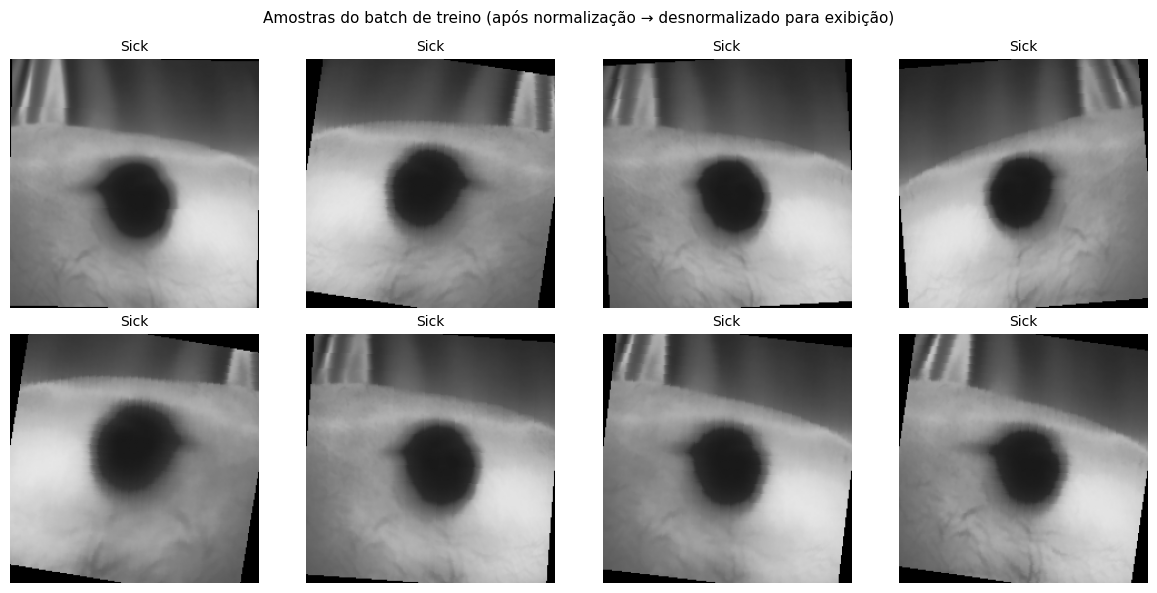

In [5]:
# Visualiza 8 frames do batch com seus labels
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Amostras do batch de treino (após normalização → desnormalizado para exibição)", fontsize=11)

for i, ax in enumerate(axes.flat):
    img = images[i, 0]  # canal único
    img_display = img * std + mean  # desnormaliza para [0, 1]
    ax.imshow(img_display.numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(CLASSES[labels[i].item()], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Configuração do dispositivo e hiperparâmetros

In [6]:
import torch.nn as nn
from src.model_cnn import ThermalCNN, build_transfer_model, train_one_epoch, evaluate_model, save_checkpoint
from src.evaluate import compute_metrics, plot_confusion_matrix, plot_roc_curve, plot_training_curves, save_results

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Dispositivo: {device}")

# Hiperparâmetros compartilhados
NUM_CLASSES   = 2
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
NUM_EPOCHS    = 3 if QUICK_TEST else 50
PATIENCE      = 2 if QUICK_TEST else 7          # early stopping
RESULTS_DIR   = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

Dispositivo: mps


In [7]:
def training_loop(model, train_loader, val_loader, model_name, lr=LR, weight_decay=WEIGHT_DECAY,
                  num_epochs=NUM_EPOCHS, patience=PATIENCE, checkpoint_path=None):
    """Loop de treinamento com early stopping no val_loss.

    Retorna dicionário com histórico de loss e acurácia por época.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_acc, val_true, val_pred = evaluate_model(model, val_loader, device)

        # Val loss para early stopping
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                val_loss += criterion(model(imgs), labels).item() * imgs.size(0)
        val_loss /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)

        improved = val_loss < best_val_loss
        marker = " ✓" if improved else ""
        print(f"[{model_name}] Época {epoch:02d}/{num_epochs} | "
              f"loss treino={train_loss:.4f} val={val_loss:.4f} | "
              f"acc treino={train_acc:.4f} val={val_acc:.4f}{marker}")

        if improved:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if checkpoint_path:
                save_checkpoint(model, checkpoint_path, epoch, optimizer)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  → Early stopping na época {epoch} (sem melhora há {patience} épocas)")
                break

    # Restaura melhor estado
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## 3. ThermalCNN (arquitetura customizada)

In [8]:
cnn_model = ThermalCNN(num_classes=NUM_CLASSES, in_channels=1)
n_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"ThermalCNN — parâmetros treináveis: {n_params:,}")

cnn_model, cnn_history = training_loop(
    cnn_model, train_loader, val_loader,
    model_name="ThermalCNN",
    checkpoint_path=str(RESULTS_DIR / "checkpoint_thermal_cnn.pth"),
)

ThermalCNN — parâmetros treináveis: 126,658
[ThermalCNN] Época 01/3 | loss treino=0.0922 val=3.9025 | acc treino=0.9890 val=0.0000 ✓
[ThermalCNN] Época 02/3 | loss treino=0.0003 val=7.6463 | acc treino=1.0000 val=0.0000
[ThermalCNN] Época 03/3 | loss treino=0.0001 val=8.8825 | acc treino=1.0000 val=0.0000
  → Early stopping na época 3 (sem melhora há 2 épocas)


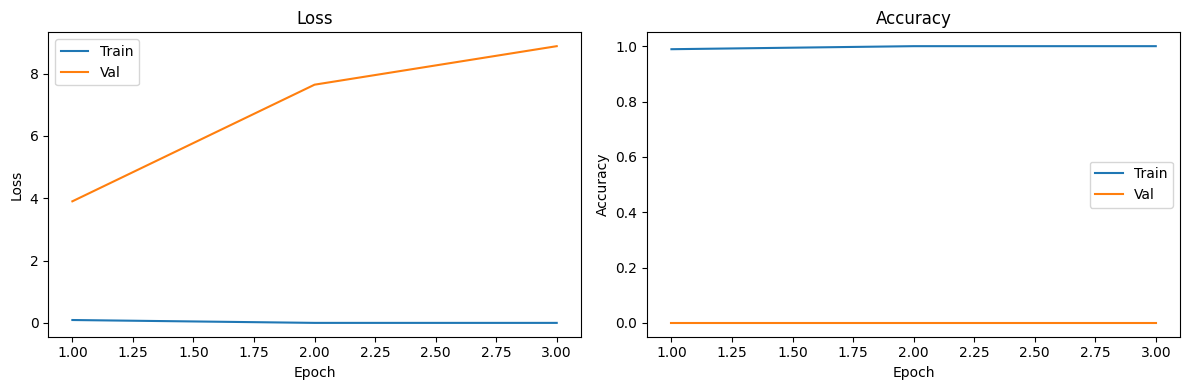

In [9]:
plot_training_curves(
    cnn_history["train_loss"], cnn_history["val_loss"],
    cnn_history["train_acc"],  cnn_history["val_acc"],
    save_path=RESULTS_DIR / "curves_thermal_cnn.png",
)

## 4. Transfer Learning — ResNet18

In [10]:
# Fase 1: backbone congelado — treina apenas a cabeça
resnet_model = build_transfer_model("resnet18", num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=True)
n_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"ResNet18 (backbone congelado) — parâmetros treináveis: {n_params:,}")

resnet_model, _ = training_loop(
    resnet_model, train_loader, val_loader,
    model_name="ResNet18-fase1",
    num_epochs=2 if QUICK_TEST else 10,
    patience=2 if QUICK_TEST else 4,
)

# Fase 2: fine-tuning completo com LR menor
for param in resnet_model.parameters():
    param.requires_grad = True

n_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"\nResNet18 (fine-tuning completo) — parâmetros treináveis: {n_params:,}")

resnet_model, resnet_history = training_loop(
    resnet_model, train_loader, val_loader,
    model_name="ResNet18-fase2",
    lr=1e-4,
    checkpoint_path=str(RESULTS_DIR / "checkpoint_resnet18.pth"),
)

ResNet18 (backbone congelado) — parâmetros treináveis: 1,026
[ResNet18-fase1] Época 01/2 | loss treino=0.0806 val=8.9275 | acc treino=0.9602 val=0.0000 ✓
[ResNet18-fase1] Época 02/2 | loss treino=0.0002 val=11.1633 | acc treino=1.0000 val=0.0000

ResNet18 (fine-tuning completo) — parâmetros treináveis: 11,171,266
[ResNet18-fase2] Época 01/3 | loss treino=0.0001 val=10.3076 | acc treino=1.0000 val=0.0000 ✓
[ResNet18-fase2] Época 02/3 | loss treino=0.0000 val=12.0550 | acc treino=1.0000 val=0.0000
[ResNet18-fase2] Época 03/3 | loss treino=0.0000 val=11.5928 | acc treino=1.0000 val=0.0000
  → Early stopping na época 3 (sem melhora há 2 épocas)


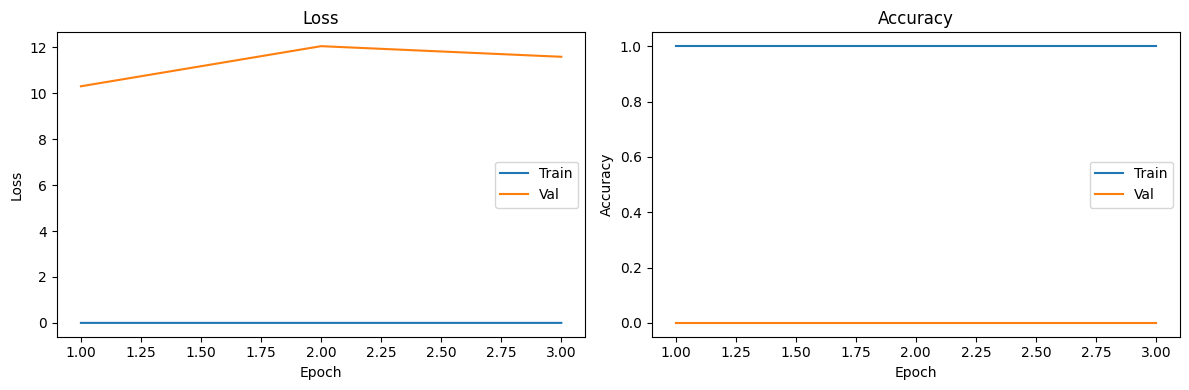

In [11]:
plot_training_curves(
    resnet_history["train_loss"], resnet_history["val_loss"],
    resnet_history["train_acc"],  resnet_history["val_acc"],
    save_path=RESULTS_DIR / "curves_resnet18.png",
)

## 5. Avaliação no conjunto de teste

In [12]:
import numpy as np
import torch.nn.functional as F

def get_test_predictions(model, loader):
    """Retorna (y_true, y_pred, y_prob) para o conjunto de teste."""
    model.eval()
    all_true, all_pred, all_prob = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            preds = logits.argmax(dim=1).cpu().tolist()
            all_true.extend(labels.tolist())
            all_pred.extend(preds)
            all_prob.extend(probs)
    return (
        np.array(all_true),
        np.array(all_pred),
        np.array(all_prob),
    )


# ThermalCNN
cnn_true, cnn_pred, cnn_prob = get_test_predictions(cnn_model, test_loader)
cnn_metrics = compute_metrics(cnn_true, cnn_pred, cnn_prob)
print("=== ThermalCNN ===")
for k, v in cnn_metrics.items():
    print(f"  {k:<12} {v:.4f}")

# ResNet18
res_true, res_pred, res_prob = get_test_predictions(resnet_model, test_loader)
res_metrics = compute_metrics(res_true, res_pred, res_prob)
print("\n=== ResNet18 ===")
for k, v in res_metrics.items():
    print(f"  {k:<12} {v:.4f}")

=== ThermalCNN ===
  accuracy     0.5019
  precision    0.2509
  recall       0.5000
  specificity  0.0000
  f1           0.3342
  auc_roc      0.5026

=== ResNet18 ===
  accuracy     0.5019
  precision    0.2509
  recall       0.5000
  specificity  0.0000
  f1           0.3342
  auc_roc      0.3934


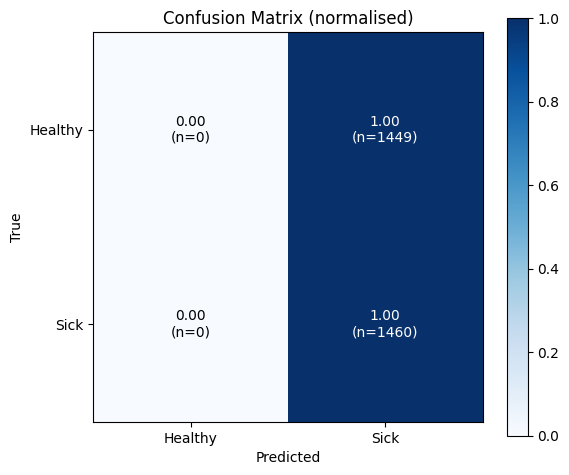

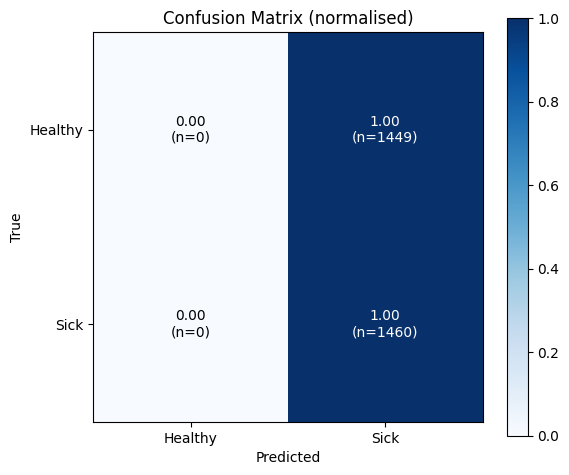

In [13]:
# Matrizes de confusão
plot_confusion_matrix(cnn_true, cnn_pred, CLASSES,
                      save_path=RESULTS_DIR / "cm_thermal_cnn.png")
plot_confusion_matrix(res_true, res_pred, CLASSES,
                      save_path=RESULTS_DIR / "cm_resnet18.png")

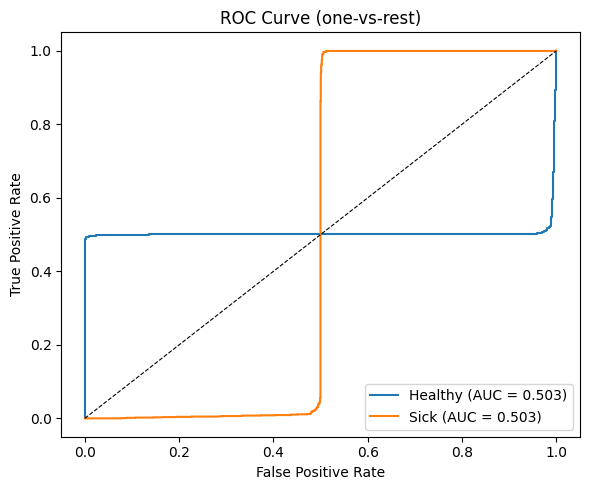

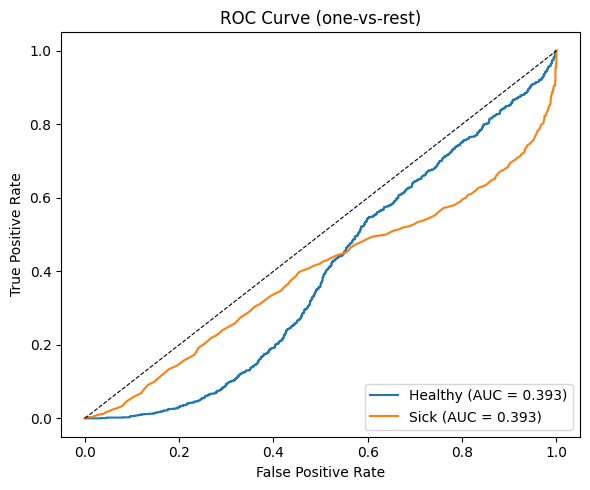

In [14]:
# Curvas ROC
plot_roc_curve(cnn_true, cnn_prob, CLASSES,
               save_path=RESULTS_DIR / "roc_thermal_cnn.png")
plot_roc_curve(res_true, res_prob, CLASSES,
               save_path=RESULTS_DIR / "roc_resnet18.png")

In [15]:
# Salva métricas no CSV de resultados
results_csv = RESULTS_DIR / "metrics.csv"
save_results(cnn_metrics, results_csv, model_name="ThermalCNN")
save_results(res_metrics, results_csv, model_name="ResNet18")
print(f"Métricas salvas em {results_csv}")

Métricas salvas em ../results/metrics.csv


## 6. Tabela comparativa (CNNs)

In [16]:
import pandas as pd

df = pd.DataFrame(
    [{"Modelo": "ThermalCNN", **cnn_metrics},
     {"Modelo": "ResNet18",   **res_metrics}]
).set_index("Modelo")

df.columns = [c.replace("_", " ").title() for c in df.columns]
df = df.round(4)
df

,Accuracy,Precision,Recall,Specificity,F1,Auc Roc
Modelo,,,,,,
ThermalCNN,0.5019,0.2509,0.5,0.0,0.3342,0.5026
ResNet18,0.5019,0.2509,0.5,0.0,0.3342,0.3934


## 7. Modelos Clássicos (SVM e Random Forest)

Features: embeddings de 256 dimensões extraídos da penúltima camada do ThermalCNN treinado.
Essa estratégia é metodologicamente mais forte que HOG/LBP porque as features já capturam
representações visuais aprendidas especificamente para o domínio térmico.

In [ ]:
from src.model_classical import (
    build_random_forest,
    build_svm,
    extract_cnn_embeddings,
    predict_classical,
    train_classical,
)

print("Extraindo embeddings (treino)...")
X_train_emb, y_train_emb = extract_cnn_embeddings(cnn_model, train_loader, device)
print("Extraindo embeddings (teste)...")
X_test_emb, y_test_emb = extract_cnn_embeddings(cnn_model, test_loader, device)
print(f"Shape treino: {X_train_emb.shape} | Shape teste: {X_test_emb.shape}")

In [ ]:
print("Treinando SVM (kernel=rbf, C=1.0)...")
svm = build_svm(kernel="rbf", C=1.0)
train_classical(svm, X_train_emb, y_train_emb)

svm_pred, svm_prob = predict_classical(svm, X_test_emb)
svm_metrics = compute_metrics(y_test_emb, svm_pred, svm_prob)
print("=== SVM ===")
for k, v in svm_metrics.items():
    print(f"  {k:<12} {v:.4f}")

In [ ]:
print("Treinando Random Forest (n_estimators=100)...")
rf = build_random_forest(n_estimators=100)
train_classical(rf, X_train_emb, y_train_emb)

rf_pred, rf_prob = predict_classical(rf, X_test_emb)
rf_metrics = compute_metrics(y_test_emb, rf_pred, rf_prob)
print("=== Random Forest ===")
for k, v in rf_metrics.items():
    print(f"  {k:<12} {v:.4f}")

In [ ]:
plot_confusion_matrix(y_test_emb, svm_pred, CLASSES,
                      save_path=RESULTS_DIR / "cm_svm.png")
plot_confusion_matrix(y_test_emb, rf_pred, CLASSES,
                      save_path=RESULTS_DIR / "cm_rf.png")
plot_roc_curve(y_test_emb, svm_prob, CLASSES,
               save_path=RESULTS_DIR / "roc_svm.png")
plot_roc_curve(y_test_emb, rf_prob, CLASSES,
               save_path=RESULTS_DIR / "roc_rf.png")

In [ ]:
save_results(svm_metrics, results_csv, model_name="SVM")
save_results(rf_metrics, results_csv, model_name="Random Forest")
print(f"Métricas dos modelos clássicos salvas em {results_csv}")

## 8. Tabela comparativa completa

In [ ]:
import pandas as pd

df_all = pd.DataFrame([
    {"Modelo": "ThermalCNN",    **cnn_metrics},
    {"Modelo": "ResNet18",      **res_metrics},
    {"Modelo": "SVM",           **svm_metrics},
    {"Modelo": "Random Forest", **rf_metrics},
]).set_index("Modelo")

df_all.columns = [c.replace("_", " ").title() for c in df_all.columns]
df_all = df_all.round(4)
df_all.style.highlight_max(axis=0, props="font-weight:bold; color:green")